In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.5)

In [3]:
mutrf = pd.DataFrame()
for file in os.listdir('results_mutrf'):
    if file.endswith('.csv'):
        data = file.split("_")[0]
        df = pd.read_csv(os.path.join('results_mutrf', file), index_col=0)
        df['data'] = data
        mutrf = pd.concat([mutrf, df], ignore_index=True)
mutrf['strategy'] = 'MutRF'

## Read FairHOME

In [5]:
fair_home = pd.DataFrame()
for file in os.listdir('baseline_intersectional'):
  if file.endswith('.txt'):
    data = file.split("_")[-1].replace('.txt', '')
    model = file.split("_")[1]
    df = pd.read_csv(os.path.join('baseline_intersectional', file), header=None, sep="\t").T
    #set the first row as column
    df.columns = df.iloc[0]
    df = df[1:]
    df['data'] = data
    df['strategy'] = f'FairHOME_{model}'
    fair_home = pd.concat([fair_home, df], ignore_index=True)

In [6]:
fair_home.drop(columns=['spd0', 'aod0', 'eod0', 'spd1', 'aod1', 'eod1'], inplace=True)

In [7]:
fair_home = fair_home[~fair_home['strategy'].isin(['FairHOME_cart', 'FairHOME_knn'])]

In [8]:
fair_home.columns = ['Accuracy', 'Recall', 'Precision', 'F1', 'MCC', 'SPD', 'AOD', 'EOD', 'AVG_SPD', 'AVG_AOD', 'AVG_EOD', 'data', 'strategy']

In [ ]:
full_data = pd.concat([mutrf, fair_home], ignore_index=True)
full_data.drop(columns=['Run'], inplace=True)

In [10]:
full_data = full_data.rename(columns={'SPD': 'WC-SPD', 'EOD': 'WC-EOD', 'AOD': 'WC-AOD', 'AVG_SPD': 'AVG-SPD', 'AVG_EOD': 'AVG-EOD', 'AVG_AOD': 'AVG-AOD'})

In [11]:
full_data

,Accuracy,Recall,Precision,F1,MCC,WC-SPD,WC-AOD,WC-EOD,AVG-SPD,AVG-AOD,AVG-EOD,data,strategy
0,0.76,0.668,0.705,0.68,0.372,0.364,0.33,0.278,0.1235,0.117,0.0735,german,MutRF
1,0.753,0.657,0.695,0.668,0.35,0.381,0.342,0.286,0.1305,0.123,0.085,german,MutRF
2,0.763,0.646,0.719,0.661,0.358,0.186,0.172,0.11,0.059,0.0405,0.039,german,MutRF
3,0.78,0.682,0.739,0.698,0.418,0.204,0.173,0.125,0.0855,0.056,0.0385,german,MutRF
4,0.78,0.693,0.735,0.707,0.426,0.066,0.059,0.049,0.039,0.036,0.03,german,MutRF
...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,0.849193,0.780847,0.801635,0.790227,0.58211,0.238187,0.114812,0.121446,0.094009,0.046696,0.054635,adult,FairHOME_rf
573,0.851552,0.782567,0.805398,0.792785,0.587522,0.238143,0.14636,0.193774,0.097511,0.055742,0.072101,adult,FairHOME_rf
574,0.849635,0.78113,0.802852,0.790887,0.583578,0.227381,0.136615,0.224664,0.088384,0.055076,0.075924,adult,FairHOME_rf
575,0.850593,0.786821,0.801849,0.793803,0.588478,0.260623,0.20419,0.298045,0.101659,0.064687,0.086768,adult,FairHOME_rf


## Pareto optimality

In [12]:
from collections import defaultdict
from itertools import product

def pareto_front_two(df,acc,fair):
    df = df.sort_values(by=[acc, fair], ascending=[False, True])
    pareto = []
    for i in range(len(df)):
        if not any((df.iloc[i][acc] <= p[acc] and
                    df.iloc[i][fair] >= p[fair]) for p in pareto):
            pareto.append(df.iloc[i])
    return pd.DataFrame(pareto)

datasets = ["adult","bank","compas","german","mep"]
metricsAcc = ['Accuracy', 'Precision', 'Recall', 'F1', 'MCC']
metricsFair = ['WC-SPD', 'WC-EOD', 'WC-AOD', 'AVG-SPD', 'AVG-EOD', 'AVG-AOD']
paretoPresent = defaultdict(int)
for dataset in datasets:
  pareto_data = defaultdict(int)
  for mAcc,mFair in product(metricsAcc,metricsFair):
    #filtered = grouped[(grouped["data"]==dataset) & (grouped["attr"]==attr)]
    filtered = full_data[(full_data["data"]==dataset)]
    if not len(filtered):
        continue
    pareto = pareto_front_two(filtered,mAcc,mFair)
    for x in pareto['strategy'].value_counts().keys():
        paretoPresent[(x,mAcc,mFair)] += 1
  #       pareto_data[x] += 1
  # if pareto_data:
  #     print(dataset)
  #     print(pd.DataFrame(pareto_data, index=[0]).T)
  #     print("----------")

In [13]:
paretoPresent

defaultdict(int,
            {('MutRF', 'Accuracy', 'WC-SPD'): 3,
             ('MutRF', 'Accuracy', 'WC-EOD'): 3,
             ('FairHOME_svm', 'Accuracy', 'WC-EOD'): 1,
             ('MutRF', 'Accuracy', 'WC-AOD'): 3,
             ('FairHOME_svm', 'Accuracy', 'WC-AOD'): 1,
             ('FairHOME_lr', 'Accuracy', 'WC-AOD'): 1,
             ('MutRF', 'Accuracy', 'AVG-SPD'): 3,
             ('FairHOME_svm', 'Accuracy', 'AVG-SPD'): 1,
             ('FairHOME_rf', 'Accuracy', 'AVG-SPD'): 2,
             ('MutRF', 'Accuracy', 'AVG-EOD'): 3,
             ('FairHOME_svm', 'Accuracy', 'AVG-EOD'): 1,
             ('FairHOME_lr', 'Accuracy', 'AVG-EOD'): 1,
             ('FairHOME_svm', 'Accuracy', 'AVG-AOD'): 1,
             ('MutRF', 'Accuracy', 'AVG-AOD'): 3,
             ('FairHOME_lr', 'Accuracy', 'AVG-AOD'): 1,
             ('MutRF', 'Precision', 'WC-SPD'): 3,
             ('MutRF', 'Precision', 'WC-EOD'): 3,
             ('FairHOME_svm', 'Precision', 'WC-EOD'): 1,
             ('FairHOME

In [14]:
df_all = pd.DataFrame(
    [(k[0], k[1], k[2], v) for k, v in paretoPresent.items()],
    columns=["method", "acc", "fair", "value"]
).fillna(0)

df_all.loc[df_all["method"] == "ad-adversarial_debiasing", "method"] = "ADV"
uniqueMethods = sorted(df_all["method"].unique())
df_all = df_all.sort_values('method')
# Create pivot tables for each metric2, reindex to include all methods, fill missing with 0
dfs = {}
df_all = df_all.sort_values('method')
for m2 in df_all["fair"].unique():
    pivot = df_all[df_all["fair"] == m2].pivot(
        index="method", columns="acc", values="value"
    )
    dfs[m2] = pivot.reindex(uniqueMethods, fill_value=0)

In [15]:
sorted_keys = sorted(dfs.keys())
dfs = {k: dfs[k] for k in sorted_keys}
dfs

{'AVG-AOD': acc           Accuracy   F1  MCC  Precision  Recall
 method                                             
 FairHOME_lr        1.0  3.0  3.0        1.0     3.0
 FairHOME_rf        NaN  NaN  NaN        NaN     1.0
 FairHOME_svm       1.0  1.0  1.0        1.0     1.0
 MutRF              3.0  3.0  3.0        3.0     3.0,
 'AVG-EOD': acc           Accuracy   F1  MCC  Precision  Recall
 method                                             
 FairHOME_lr        1.0  3.0  3.0        3.0     3.0
 FairHOME_rf        NaN  NaN  NaN        1.0     1.0
 FairHOME_svm       1.0  1.0  1.0        1.0     1.0
 MutRF              3.0  3.0  3.0        3.0     3.0,
 'AVG-SPD': acc           Accuracy   F1  MCC  Precision  Recall
 method                                             
 FairHOME_lr        1.0  2.0  1.0        1.0     2.0
 FairHOME_rf        2.0  2.0  1.0        NaN     2.0
 FairHOME_svm       1.0  1.0  2.0        1.0     2.0
 MutRF              3.0  3.0  3.0        3.0     3.0,
 'WC-AOD':

In [16]:
rename_dict = {
  'FairHOME_lr': 'FairHOME-LR',
  'FairHOME_svm': 'FairHOME-SVM',
  'FairHOME_rf': 'FairHOME-RF',
  'MutRF': 'FairRF'} 
dfs['WC-SPD'] = dfs['WC-SPD'].rename(index=rename_dict).fillna(0)
dfs['WC-EOD'] = dfs['WC-EOD'].rename(index=rename_dict).fillna(0)
dfs['WC-AOD'] = dfs['WC-AOD'].rename(index=rename_dict).fillna(0)
dfs['AVG-SPD'] = dfs['AVG-SPD'].rename(index=rename_dict).fillna(0)
dfs['AVG-EOD'] = dfs['AVG-EOD'].rename(index=rename_dict).fillna(0)
dfs['AVG-AOD'] = dfs['AVG-AOD'].rename(index=rename_dict).fillna(0)

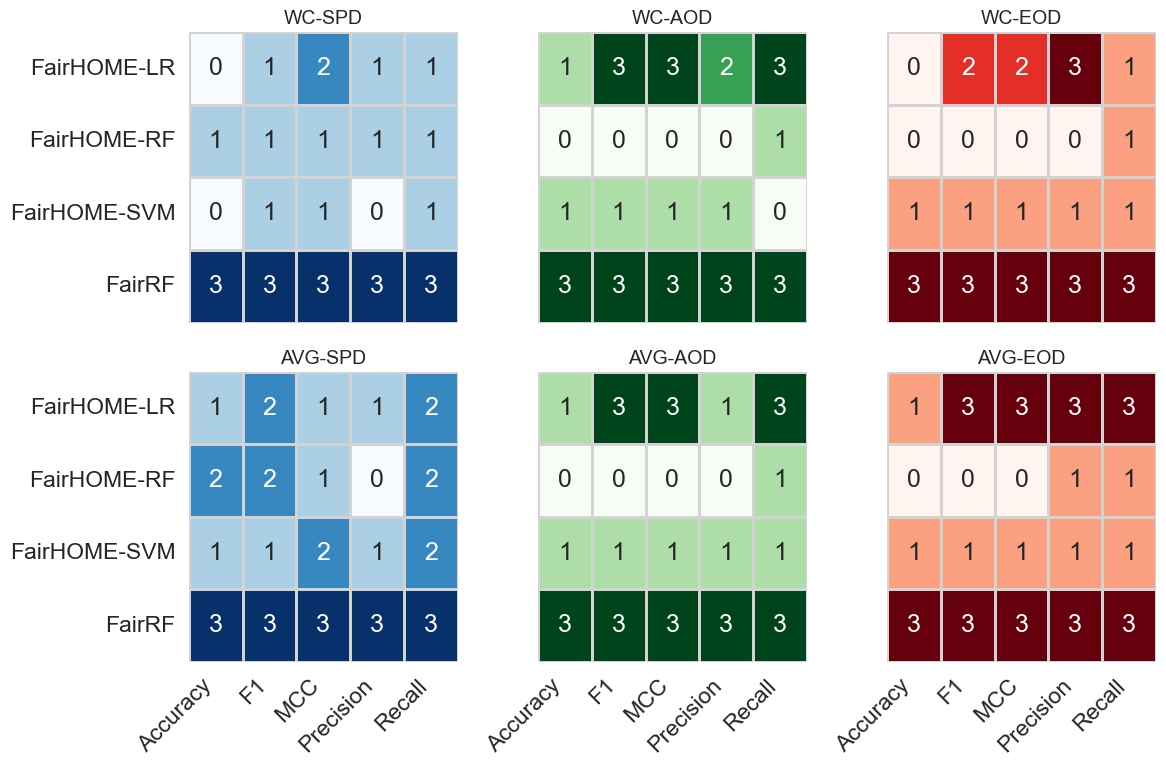

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharey=True)

# Replace with your real keys
keys = ["WC-SPD", "WC-AOD", "WC-EOD", "AVG-SPD", "AVG-AOD", "AVG-EOD"]
cols = {"WC-SPD":"Blues","WC-AOD":"Greens","WC-EOD":"Reds","AVG-SPD":"Blues","AVG-AOD":"Greens","AVG-EOD":"Reds"}
for i, (ax, key) in enumerate(zip(axes.flatten(), keys)):
    sns.heatmap(
        dfs[key],
        cmap=cols[key],
        linewidths=1,
        linecolor="lightgrey",
        annot=True,
        cbar=False,
        ax=ax
    )
    
    # Remove x-axis labels
    ax.set_xlabel(None)
    ax.set_ylabel("")  

    # Remove x-labels if not bottom row
    if i < 3:
        ax.set_xticks([])
    else:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_title(key, fontsize=14)

plt.tight_layout()
plt.savefig("imgs/heatmaps_combined-intersec.pdf", bbox_inches="tight")
plt.show()

## Average scores by dataset

In [18]:
full_data.groupby(['data', 'strategy']).mean().reset_index()

,data,strategy,Accuracy,Recall,Precision,F1,MCC,WC-SPD,WC-AOD,WC-EOD,AVG-SPD,AVG-AOD,AVG-EOD
0,adult,FairHOME_lr,0.84302,0.756513,0.800367,0.773947,0.555126,0.17599,0.052725,0.090911,0.072341,0.019458,0.031783
1,adult,FairHOME_rf,0.848706,0.781685,0.801507,0.790609,0.582831,0.243272,0.13875,0.177494,0.0976,0.054459,0.067354
2,adult,FairHOME_svm,0.844818,0.757364,0.804019,0.775719,0.559422,0.175178,0.046623,0.086578,0.070965,0.016781,0.029164
3,adult,MutRF,0.854614,0.758992,0.828669,0.783528,0.583228,0.193811,0.10878,0.15915,0.120177,0.054992,0.072626
4,compas,FairHOME_lr,0.66121,0.642332,0.67883,0.63385,0.319042,0.193449,0.160915,0.094032,0.084379,0.068721,0.036805
5,compas,FairHOME_rf,0.665073,0.651941,0.669054,0.649828,0.32052,0.217159,0.176169,0.127265,0.091025,0.071733,0.050592
6,compas,FairHOME_svm,0.656267,0.638363,0.66938,0.631055,0.306149,0.192185,0.160872,0.095223,0.083203,0.067824,0.037341
7,compas,MutRF,0.65939,0.646314,0.667709,0.639971,0.31225,0.188797,0.157517,0.109564,0.118055,0.092346,0.060201
8,german,FairHOME_lr,0.745167,0.667862,0.698071,0.675733,0.364158,0.149927,0.141172,0.132818,0.051228,0.047002,0.043287
9,german,FairHOME_rf,0.754167,0.647624,0.721362,0.658872,0.361024,0.128654,0.125711,0.105323,0.041844,0.040417,0.033988
